# Notebook 02 – EDA & Statistical Hypothesis Testing
Comprehensive exploratory analysis and three formal statistical hypotheses.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
os.makedirs('../reports/figures', exist_ok=True)

DATA_PATH = '../data/processed/heart_clean.csv'
if not os.path.exists(DATA_PATH):
    from src.data_prep import generate_synthetic_data, clean_data, impute_missing_values
    df = impute_missing_values(clean_data(generate_synthetic_data()))
else:
    df = pd.read_csv(DATA_PATH)

print("Dataset loaded:", df.shape)
df.head()


Dataset loaded: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,37.0,0,0,146.0,197.0,1,1,182.0,0,0.5,2,0.0,3,0
1,55.0,0,1,130.0,334.0,1,1,171.0,0,0.3,2,3.0,3,0
2,59.0,0,2,126.0,246.0,1,1,127.0,1,4.9,0,1.0,2,1
3,46.0,1,0,105.0,212.0,1,0,153.0,0,0.2,0,0.0,1,0
4,41.0,0,0,123.0,174.0,1,0,119.0,0,1.6,2,1.0,3,1


## 1. Target Distribution

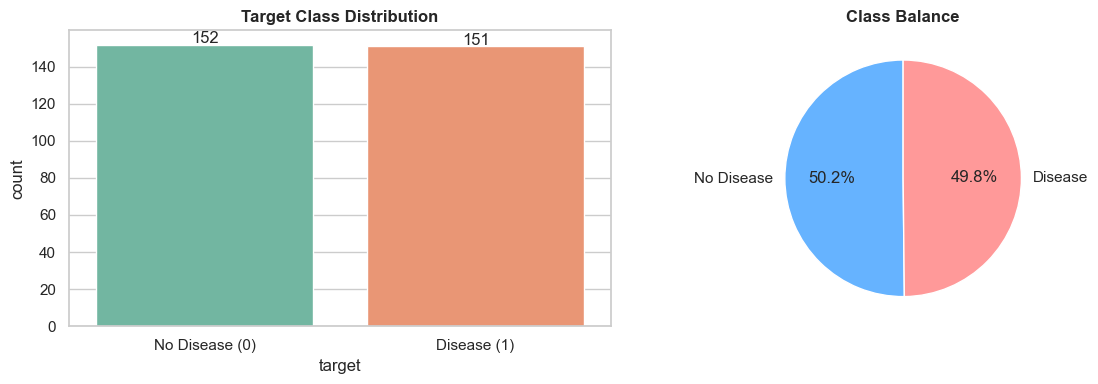

Class distribution: {0: 152, 1: 151}


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x='target', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()+1), ha='center')

# Pie chart
sizes = df['target'].value_counts().values
axes[1].pie(sizes, labels=['No Disease', 'Disease'], autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
axes[1].set_title('Class Balance', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Class distribution:", df['target'].value_counts().to_dict())


## 2. Univariate Distributions – Histograms & KDEs

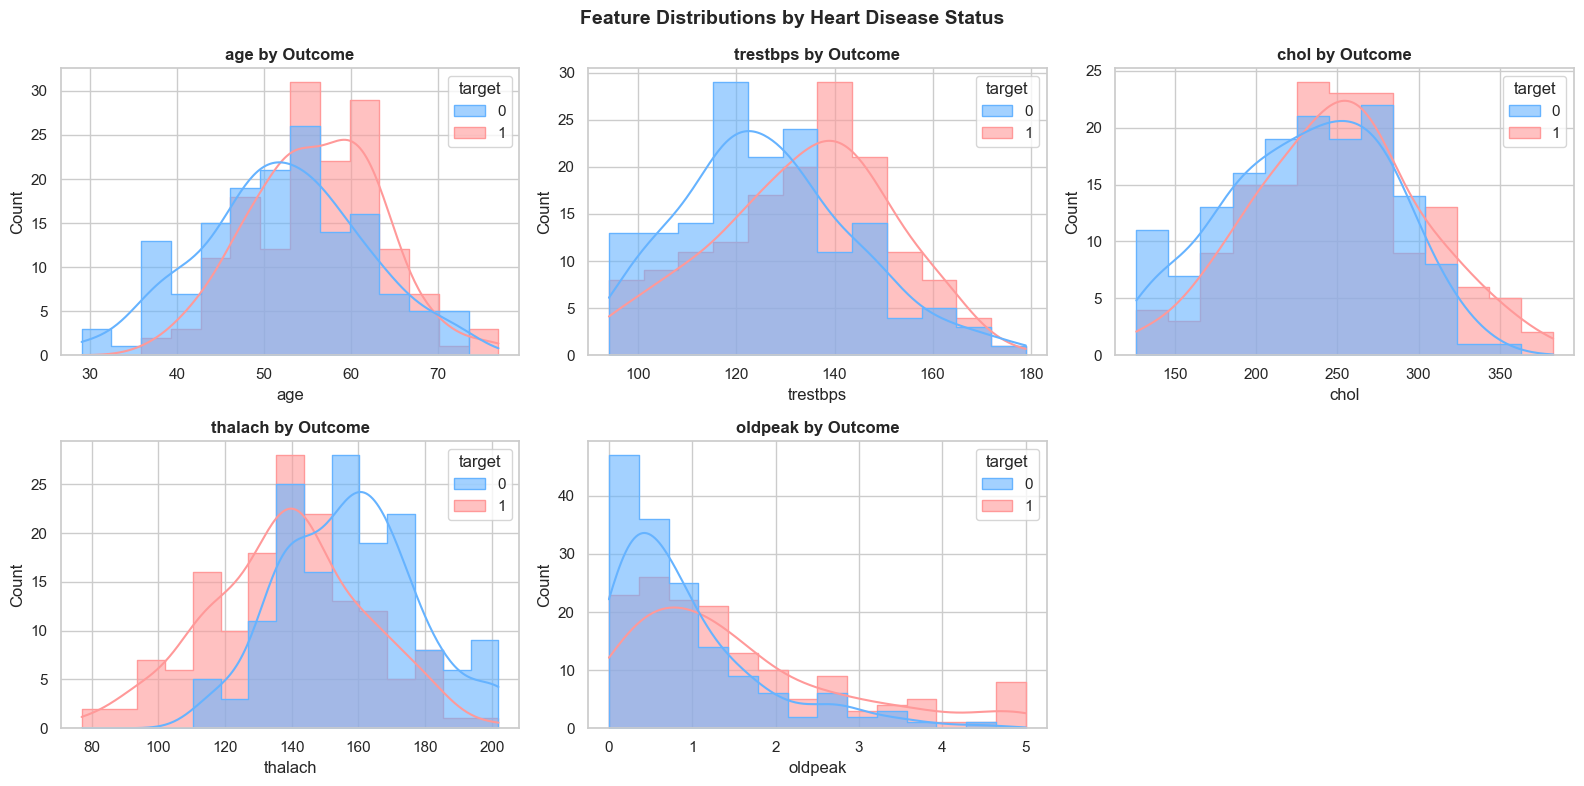

In [3]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=axes[i],
                 palette=['#66b3ff','#ff9999'], alpha=0.6, element='step')
    axes[i].set_title(f'{col} by Outcome', fontweight='bold')

axes[-1].axis('off')
plt.suptitle('Feature Distributions by Heart Disease Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/univariate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Correlation Heatmap

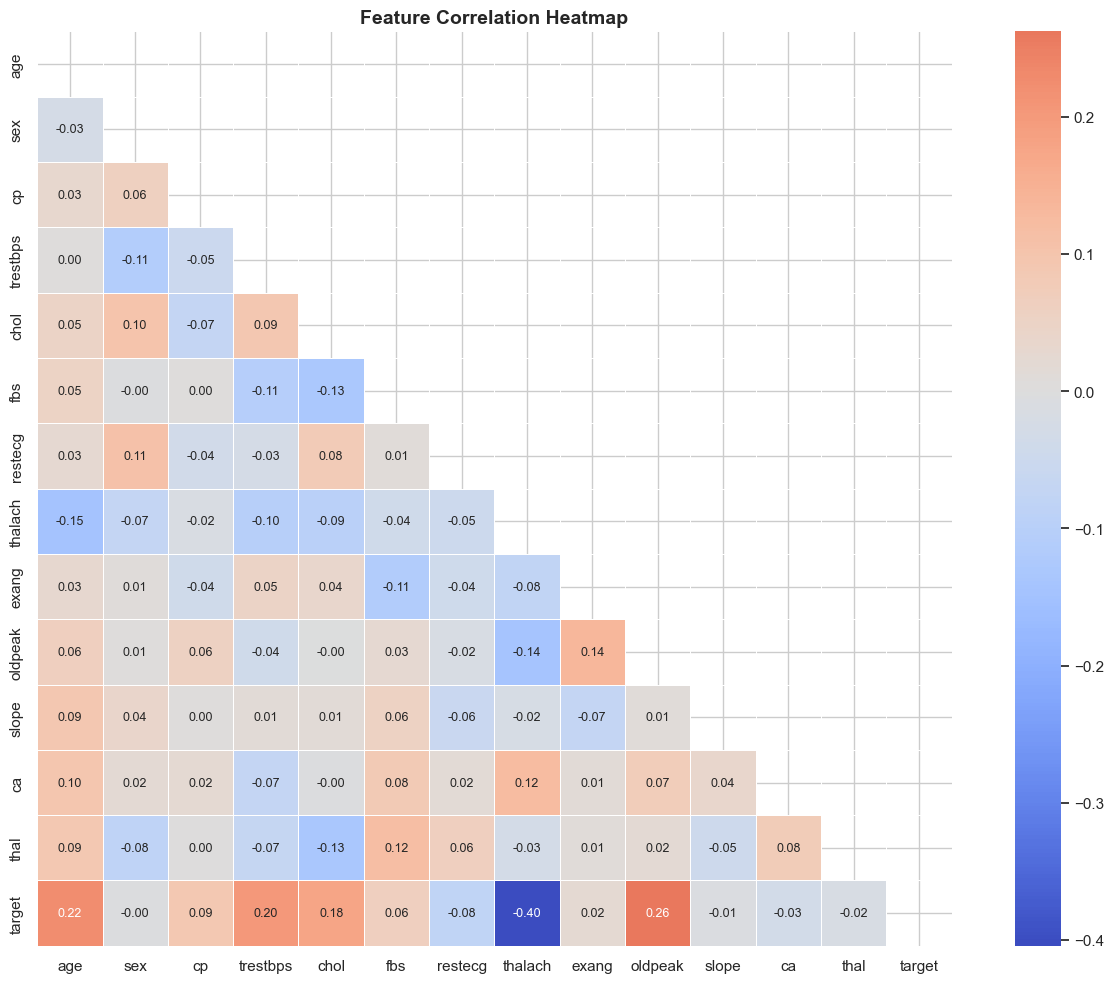

In [4]:
fig, ax = plt.subplots(figsize=(13, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, square=True, annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Bivariate Analysis – Pairplots

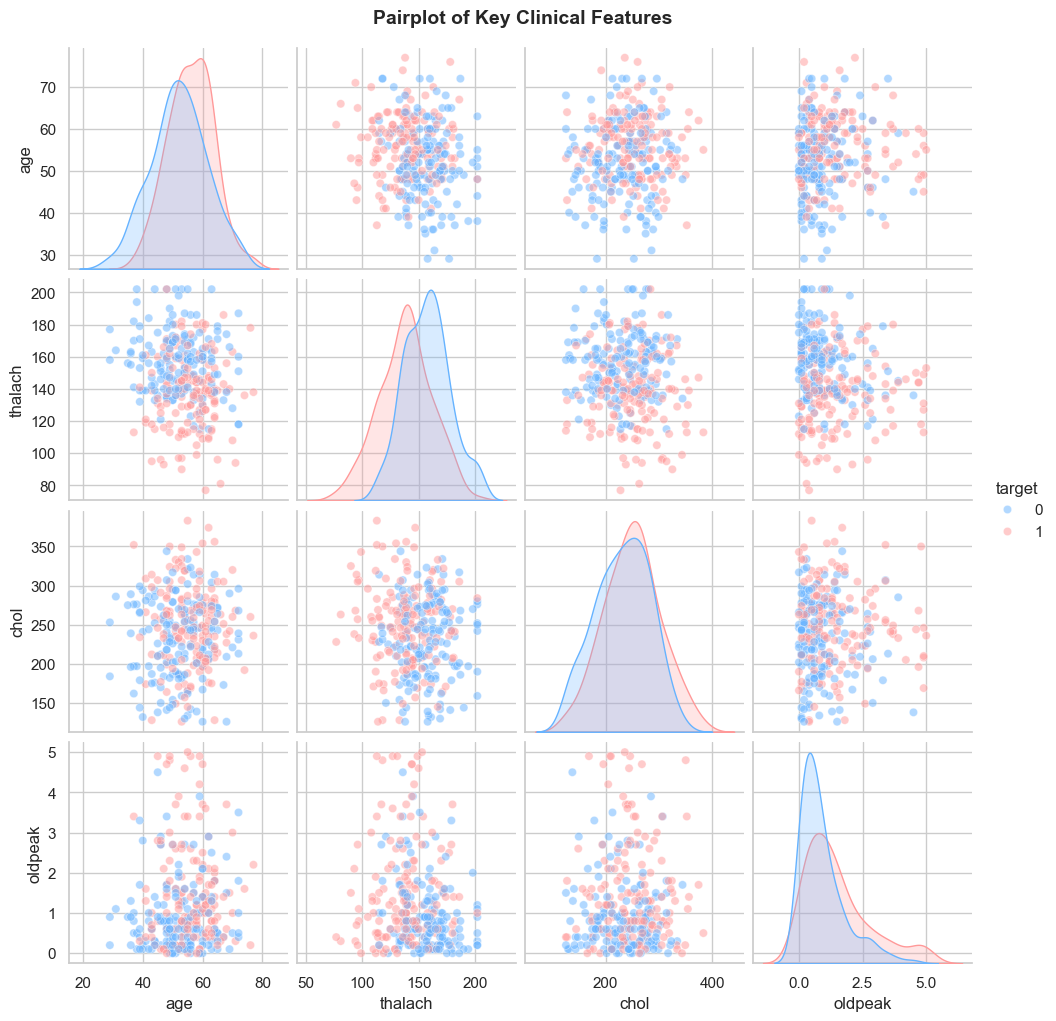

In [5]:
pair_cols = ['age', 'thalach', 'chol', 'oldpeak', 'target']
g = sns.pairplot(df[pair_cols], hue='target', palette=['#66b3ff','#ff9999'],
                 plot_kws={'alpha': 0.5}, diag_kind='kde')
g.fig.suptitle('Pairplot of Key Clinical Features', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('../reports/figures/pairplot.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Statistical Hypothesis Testing

### Hypothesis 1: Max Heart Rate (thalach) differs between disease groups

In [6]:
group0 = df[df['target']==0]['thalach']
group1 = df[df['target']==1]['thalach']

# Test normality (Shapiro-Wilk)
stat0, p_norm0 = stats.shapiro(group0)
stat1, p_norm1 = stats.shapiro(group1)
print(f"Shapiro-Wilk – No Disease: stat={stat0:.4f}, p={p_norm0:.4f}")
print(f"Shapiro-Wilk – Disease   : stat={stat1:.4f}, p={p_norm1:.4f}")

# Levene's test for equal variances
lev_stat, lev_p = stats.levene(group0, group1)
print(f"Levene's Test: stat={lev_stat:.4f}, p={lev_p:.4f}")

# Independent t-test (or Mann-Whitney U if assumptions fail)
if p_norm0 > 0.05 and p_norm1 > 0.05 and lev_p > 0.05:
    t_stat, p_val = stats.ttest_ind(group0, group1)
    test_name = "Independent t-test"
else:
    t_stat, p_val = stats.mannwhitneyu(group0, group1, alternative='two-sided')
    test_name = "Mann-Whitney U"

# Effect size – Cohen's d
pooled_std = np.sqrt((group0.std()**2 + group1.std()**2) / 2)
cohen_d = (group0.mean() - group1.mean()) / pooled_std

print(f"\n--- Hypothesis 1: Max Heart Rate vs Outcome ---")
print(f"Test used    : {test_name}")
print(f"Test stat    : {t_stat:.4f}")
print(f"p-value      : {p_val:.6f}")
print(f"Cohen's d    : {cohen_d:.4f}")
print(f"Conclusion   : {'REJECT H0 – significant difference' if p_val < 0.05 else 'FAIL to reject H0'}")


Shapiro-Wilk – No Disease: stat=0.9824, p=0.0493
Shapiro-Wilk – Disease   : stat=0.9928, p=0.6509
Levene's Test: stat=2.0621, p=0.1520

--- Hypothesis 1: Max Heart Rate vs Outcome ---
Test used    : Mann-Whitney U
Test stat    : 16705.5000
p-value      : 0.000000
Cohen's d    : 0.8808
Conclusion   : REJECT H0 – significant difference


### Hypothesis 2: Cholesterol differs between disease groups (ANOVA)

In [7]:
# ANOVA across chest pain types (cp: 0-3)
groups_by_cp = [df[df['cp']==i]['chol'].dropna() for i in range(4)]
f_stat, p_val2 = stats.f_oneway(*groups_by_cp)

print("--- Hypothesis 2: Cholesterol across Chest Pain Types (ANOVA) ---")
print(f"F-statistic  : {f_stat:.4f}")
print(f"p-value      : {p_val2:.6f}")
print(f"Conclusion   : {'REJECT H0 – significant cholesterol difference across CP types' if p_val2 < 0.05 else 'FAIL to reject H0'}")

# Group means
for i in range(4):
    print(f"  CP type {i}: mean chol = {df[df['cp']==i]['chol'].mean():.2f}")


--- Hypothesis 2: Cholesterol across Chest Pain Types (ANOVA) ---
F-statistic  : 3.3462
p-value      : 0.019523
Conclusion   : REJECT H0 – significant cholesterol difference across CP types
  CP type 0: mean chol = 242.27
  CP type 1: mean chol = 240.08
  CP type 2: mean chol = 253.49
  CP type 3: mean chol = 227.21


### Hypothesis 3: Sex & Heart Disease – Chi-squared Independence Test

--- Hypothesis 3: Sex vs Heart Disease (Chi-squared) ---
Contingency Table:
target   0   1
sex           
0       78  78
1       74  73

Chi2 statistic : 0.0000
Degrees of freedom: 1
p-value        : 1.000000
Conclusion     : FAIL to reject H0


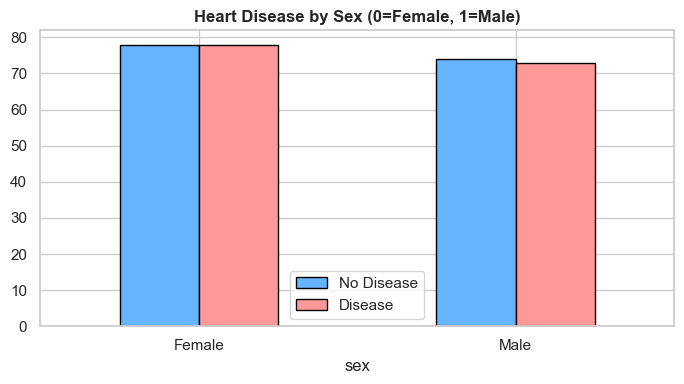

In [8]:
contingency = pd.crosstab(df['sex'], df['target'])
chi2_stat, p_val3, dof, expected = stats.chi2_contingency(contingency)

print("--- Hypothesis 3: Sex vs Heart Disease (Chi-squared) ---")
print(f"Contingency Table:\n{contingency}")
print(f"\nChi2 statistic : {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value        : {p_val3:.6f}")
print(f"Conclusion     : {'REJECT H0 – sex is associated with disease status' if p_val3 < 0.05 else 'FAIL to reject H0'}")

# Visualise
fig, ax = plt.subplots(figsize=(7, 4))
contingency.plot(kind='bar', ax=ax, color=['#66b3ff','#ff9999'], edgecolor='black')
ax.set_title('Heart Disease by Sex (0=Female, 1=Male)', fontweight='bold')
ax.set_xticklabels(['Female', 'Male'], rotation=0)
ax.legend(['No Disease', 'Disease'])
plt.tight_layout()
plt.savefig('../reports/figures/sex_disease_barplot.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Summary of Statistical Findings

In [9]:
print("="*60)
print("STATISTICAL HYPOTHESIS TESTING SUMMARY")
print("="*60)
print(f"H1 (thalach vs target): p={p_val:.6f} → {'SIGNIFICANT' if p_val<0.05 else 'Not significant'}, Cohen's d={cohen_d:.3f}")
print(f"H2 (chol across CP)   : p={p_val2:.6f} → {'SIGNIFICANT' if p_val2<0.05 else 'Not significant'}")
print(f"H3 (sex × target)     : p={p_val3:.6f} → {'SIGNIFICANT' if p_val3<0.05 else 'Not significant'}")
print("="*60)


STATISTICAL HYPOTHESIS TESTING SUMMARY
H1 (thalach vs target): p=0.000000 → SIGNIFICANT, Cohen's d=0.881
H2 (chol across CP)   : p=0.019523 → SIGNIFICANT
H3 (sex × target)     : p=1.000000 → Not significant
